# Broward County Home Prices & the 2008 Property Tax Amendment

**Research question:** Did Florida's 2008 property tax amendment (Amendment 1 — increased homestead exemption + Save Our Homes portability) correlate with a shift in Broward County home price growth, controlling for the broader housing market trend (i.e., the 2008 crash)?

**Why a control matters:** Amendment 1 took effect in January 2008, right as the national housing market collapsed. A naive before/after comparison of Broward alone would mostly be picking up the crash, not the policy. This notebook uses a difference-in-differences (DiD) style design: compare Broward's trend to a national benchmark, so the crash effect is differenced out and what's left is closer to a Broward/Florida-specific effect.

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Data you'll need

Download these two CSVs from FRED (free, no account/API key needed) and put them in a `data/` folder next to this notebook:

- **Broward home price index:** FRED series `ATNHPIUS12011Q` — https://fred.stlouisfed.org/series/ATNHPIUS12011Q
- **National benchmark:** FRED series `USSTHPI` — https://fred.stlouisfed.org/series/USSTHPI

On each FRED page: click **Download** → CSV. Rename the files `broward_hpi.csv` and `national_hpi.csv`.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

pd.set_option('display.max_rows', 10)

## 2. Load and merge the two series

In [18]:
broward = pd.read_csv('data/broward_hpi.csv')
national = pd.read_csv('data/national_hpi.csv')

# FRED CSVs typically have columns like 'observation_date' and the series ID.
# Rename them to something consistent so the merge is easy.
broward.columns = ['date', 'broward_hpi']
national.columns = ['date', 'national_hpi']

broward['date'] = pd.to_datetime(broward['date'])
national['date'] = pd.to_datetime(national['date'])

df = pd.merge(broward, national, on='date', how='inner').sort_values('date').reset_index(drop=True)
df.head()

,date,broward_hpi,national_hpi
0,1975-01-01,42.68,61.16
1,1976-01-01,39.78,65.57
2,1977-01-01,39.64,73.43
3,1978-01-01,43.08,83.66
4,1979-01-01,45.61,95.13


## 3. Compute growth rates

We care about *growth*, not raw index levels, so both series are comparable.

In [23]:
df['broward_growth'] = df['broward_hpi'].pct_change(1) * 100  # year-over-year % growth (annual data)
df['national_growth'] = df['national_hpi'].pct_change(1) * 100
df = df.dropna().reset_index(drop=True)
df.head()

,date,broward_hpi,national_hpi,broward_growth,national_growth,post,post_x_national
0,1977-01-01,39.64,73.43,-0.351936,11.987189,0,0.0
1,1978-01-01,43.08,83.66,8.678103,13.931636,0,0.0
2,1979-01-01,45.61,95.13,5.872795,13.710256,0,0.0
3,1980-01-01,52.15,102.65,14.338961,7.904972,0,0.0
4,1981-01-01,52.60,107.17,0.862895,4.403312,0,0.0


## 4. Visualize the trend around 2008

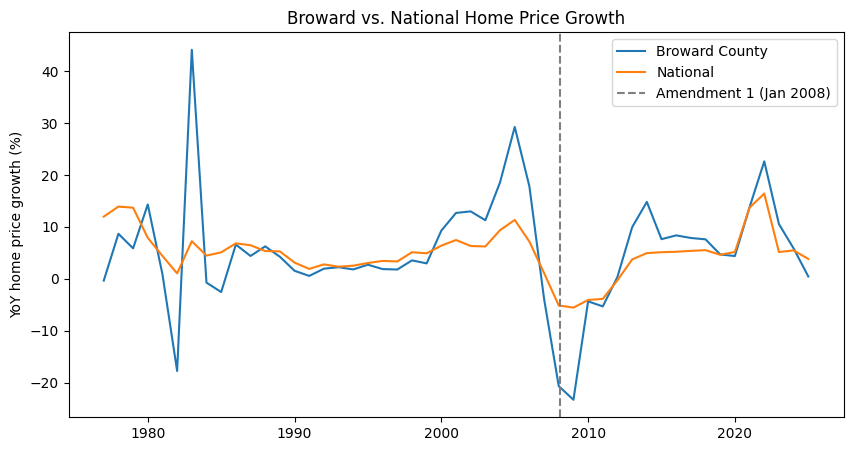

In [24]:
import os
os.makedirs('figures', exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df['date'], df['broward_growth'], label='Broward County')
ax.plot(df['date'], df['national_growth'], label='National')
ax.axvline(pd.Timestamp('2008-01-29'), color='gray', linestyle='--', label='Amendment 1 (Jan 2008)')
ax.set_ylabel('YoY home price growth (%)')
ax.set_title('Broward vs. National Home Price Growth')
ax.legend()
plt.savefig('figures/broward_vs_national.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Difference-in-differences regression

We test whether the **gap** between Broward and the national trend shifted after Amendment 1, beyond what the national trend alone would predict.

`broward_growth = β0 + β1(post) + β2(national_growth) + β3(post × national_growth) + ε`

- `post` = 1 for observations after Jan 2008, 0 before
- `β1` is the key coefficient: it captures the shift in Broward's growth tied to the policy period, after controlling for what the national market was doing

In [25]:
df['post'] = (df['date'] >= '2008-01-29').astype(int)
df['post_x_national'] = df['post'] * df['national_growth']

X = df[['post', 'national_growth', 'post_x_national']]
X = sm.add_constant(X)
y = df['broward_growth']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         broward_growth   R-squared:                       0.471
Model:                            OLS   Adj. R-squared:                  0.435
Method:                 Least Squares   F-statistic:                     13.34
Date:                Mon, 21 Sep 2026   Prob (F-statistic):           2.32e-06
Time:                        17:39:57   Log-Likelihood:                -171.09
No. Observations:                  49   AIC:                             350.2
Df Residuals:                      45   BIC:                             357.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -4.2725      2.579     

In [26]:
model_robust = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 2})
print(model_robust.summary())

                            OLS Regression Results                            
Dep. Variable:         broward_growth   R-squared:                       0.471
Model:                            OLS   Adj. R-squared:                  0.435
Method:                 Least Squares   F-statistic:                     13.59
Date:                Mon, 21 Sep 2026   Prob (F-statistic):           1.92e-06
Time:                        17:40:02   Log-Likelihood:                -171.09
No. Observations:                  49   AIC:                             350.2
Df Residuals:                      45   BIC:                             357.8
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -4.2725      2.851     

## 6. Interpret

Look at the coefficient on `post` and its p-value:
- **Significant** → Broward's growth shifted relative to the national trend around the policy change (correlation, not proof of causation — plenty else happened in 2008).
- **Not significant** → no detectable shift beyond the national crash itself.

### Honest limitations to write up
- 2008 had *many* confounding events (subprime crisis, foreclosure wave, credit freeze) — Amendment 1 is one policy among many things happening at once.
- A national benchmark is a blunt control. A sharper version compares Broward/Florida to a few similar Sun Belt states *without* a comparable exemption change that year, or compares homesteaded vs. non-homesteaded properties within Florida (only homesteaded properties got the bigger benefit boost).
- Consider also testing **turnover** (sales volume), not just price — Broward County Property Appraiser or Florida Realtors publish historical sales counts.


## Next steps
- Pull Florida Realtors or Property Appraiser sales-volume data for a turnover measure
- Try the homestead vs. non-homestead comparison as a sharper DiD design
- Write a 1-page summary of findings + limitations for your portfolio